In [3]:
import matplotlib.pyplot as plt
from matplotlib import rc
import matplotlib.colors as mcolors
import matplotlib as mpl 
import numpy as np

_dpi = 50


def colormap(num_colors, name = 'rainbow') :
    cmap = mpl.cm.get_cmap(name = name, lut = num_colors)
    return cmap(range(num_colors))

rc('text', usetex=True)
rc('font', family='serif', size = 18)

_R = 8.314

In [72]:
def L(T, DfusH, Tfus) : 
    return DfusH/_R * (1/T - 1/Tfus)

#def xB_l(T, DfusHA, DfusHB, TfusA, TfusB) : 
#    return (np.exp(L(T, DfusHA, TfusA)) - 1) / (np.exp(L(T, DfusHB, TfusB)) - np.exp(L(T, DfusHA, TfusA)))

#def xB_s(T, DfusHA, DfusHB, TfusA, TfusB) : 
#    return (np.exp(L(T, DfusHA, TfusA)) - 1) / (np.exp(L(T, DfusHA, TfusA)) - np.exp(L(T, DfusHB, TfusB))) * np.exp(L(T, DfusHB, TfusB))

def xB_l_1(T, DfusHA, TfusA) : 
    return 1 - np.exp( - L(T, DfusHA, TfusA))

def xB_l_2(T, DfusHB, TfusB) : 
    return np.exp(- L(T, DfusHB, TfusB))


#def xB_s(T, DfusHA, DfusHB, TfusA, TfusB) : 
#    return (np.exp(L(T, DfusHA, TfusA)) - 1) / (np.exp(L(T, DfusHA, TfusA)) - np.exp(L(T, DfusHB, TfusB))) * np.exp(L(T, DfusHB, TfusB))

# Diagramme $AgCl - ZnCl_2$, mélange hétérogène

[9575.67068312]
[27780.45852537]


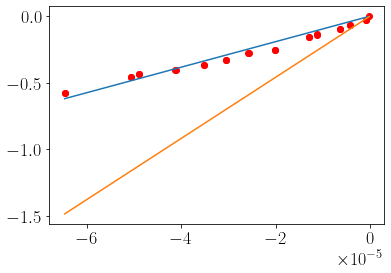

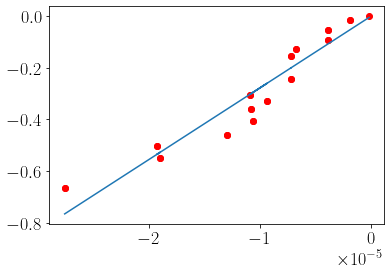

In [116]:
from scipy.optimize import curve_fit

x_exp, Tliq_exp, TE_exp = np.loadtxt("Fig03a.csv", delimiter = ",", skiprows = 1).T

TfusA = 587 #283 + 273.15
TfusB = 728 #455 + 273.15

y = lambda x, a : a *x



mask = x_exp > 0.5
fig = plt.figure()

x = 1/_R * (1/TfusB - 1/Tliq_exp[mask])#, np.log(x_exp)) 
p1, pcov = curve_fit(y, x, np.log(x_exp)[mask])
print(p1)
plt.plot(x, np.log(x_exp)[mask], 'ro')
plt.plot(x, p1*x)

plt.plot(x, 27 * 10**3 * 0.85 * x)

mask = x_exp < 0.5

x = 1/_R * (1/TfusA - 1/Tliq_exp[mask])#, np.log(x_exp)) 

fig = plt.figure()
p2, pcov = curve_fit(y, x, np.log(1-x_exp)[mask])
print(p2)
plt.plot(x, np.log(1-x_exp)[mask], 'ro')
plt.plot(x, p2*x)



22950.0 8500.0


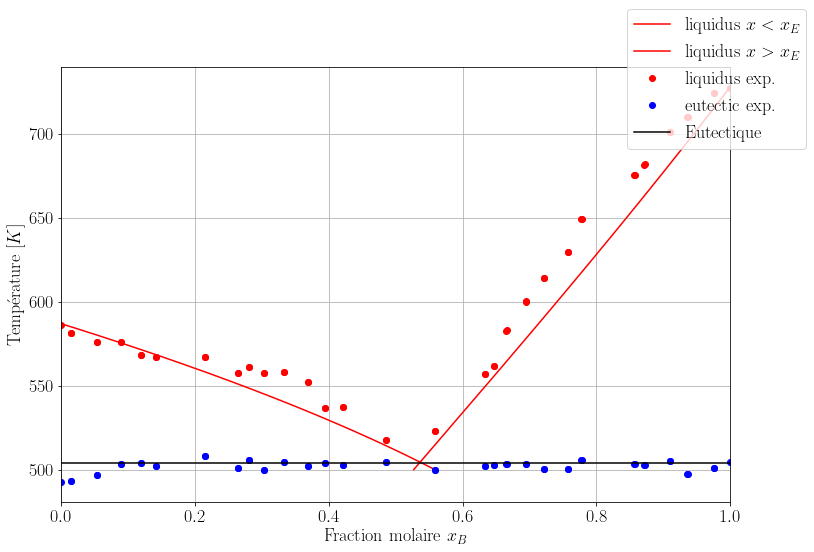

In [120]:
#TfusA = 96 + 273.15
#TfusB = 80 + 273.15
#DfusHA = 23.22 * 10**3
#DfusHB = 19.44 * 10**3

TfusA = 587#283 + 273.15
TfusB = 728 #455 + 273.15
DfusHA = 27 * 10**3 * 0.85
DfusHB = 10 * 10**3 * 0.85

print(DfusHA, DfusHB)

x_exp, Tliq_exp, TE_exp = np.loadtxt("Fig03a.csv", delimiter = ",", skiprows = 1).T
#Tliq_exp += 273.15
#TE_exp += 273.15

#TfusA = 100 + 273.15
#TfusB = 801 + 273.15
#DfusHA = 6 * 10**3
#DfusHB = 28.5 * 10**3
#MA = 18.02
#MB = 58.44

T = np.linspace(500, TfusB, num = 1000)


fig = plt.figure(figsize = (12,8))
ax = fig.subplots()

xB_1 = xB_l_1(T, DfusHA, TfusA)
xB_2 = xB_l_2(T, DfusHB, TfusB)

ax.plot(xB_1, T, label = "liquidus $x < x_E$", color = 'red')
ax.plot(xB_2, T, label = "liquidus $x > x_E$", color = 'red')

ax.plot(x_exp, Tliq_exp, label = "liquidus exp.", color = 'red', ls = 'none', marker = 'o')
ax.plot(x_exp, TE_exp, label = "eutectic exp.", color = 'blue', ls = 'none', marker = 'o')

ax.axhline(y = 504, color = 'black', label = 'Eutectique')
#ax.axvline(x = 0.535)

#ax.set_xlim(0,1)

ax.set_ylabel("Température [$K$]")
ax.set_xlabel("Fraction molaire $x_B$")
ax.grid()

ax.set_xlim(0,1)

fig.legend()

fig.savefig("Fig03a", dpi = _dpi)

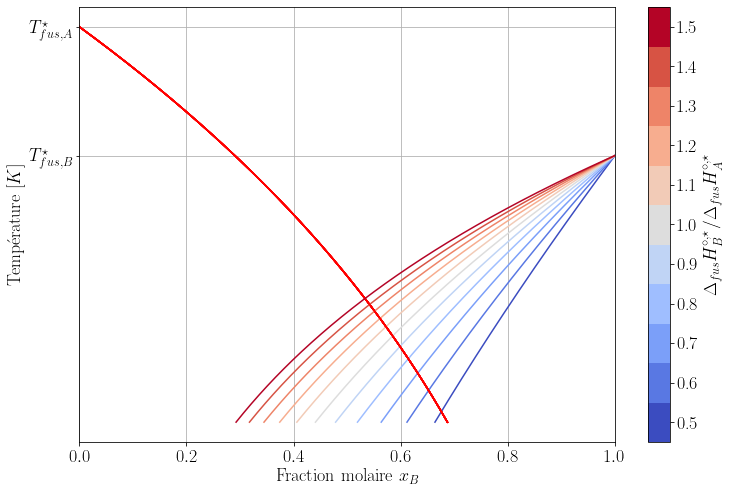

In [129]:
TfusA = 96 + 273.15
TfusB = 80 + 273.15
DfusHA = 23.22 * 10**3
DfusHB = DfusHA * np.linspace(0.5, 1.5, num = 11)

pen_matplotlib=colormap(len(DfusHB), name = "coolwarm")

T = np.linspace(320, TfusA, num = 1000)


fig = plt.figure(figsize = (12,8))
ax = fig.subplots()

for n in range(len(DfusHB)) :
    ax.plot(xB_l_1(T, DfusHA, TfusA), T, color = 'red')
    ax.plot(xB_l_2(T, DfusHB[n], TfusB), T, color = pen_matplotlib[n])

    ax.set_xlim(0,1)

ax.set_ylabel("Température [$K$]")
ax.set_xlabel("Fraction molaire $x_B$")
ax.grid()

ax.set_yticks([TfusA, TfusB])
ax.set_yticklabels(["$T_{fus,A}^\star$", "$T_{fus,B}^\star$"])

# Create a colorbar with discrete color labels
bounds = np.arange(len(pen_matplotlib)+1) - 0.5
cmap= mcolors.ListedColormap(pen_matplotlib)
sm = plt.cm.ScalarMappable(cmap=cmap)
sm.set_array([])  # This step is necessary to create a mappable
cbar = plt.colorbar(sm, ticks=np.arange(len(pen_matplotlib)), boundaries = bounds)
cbar.set_ticklabels(np.round(DfusHB/DfusHA, 1))
cbar.set_label('$\Delta_{fus} H^{\circ, \star}_B / \Delta_{fus} H^{\circ, \star}_A$')


fig.savefig("Fig03b", dpi = _dpi)

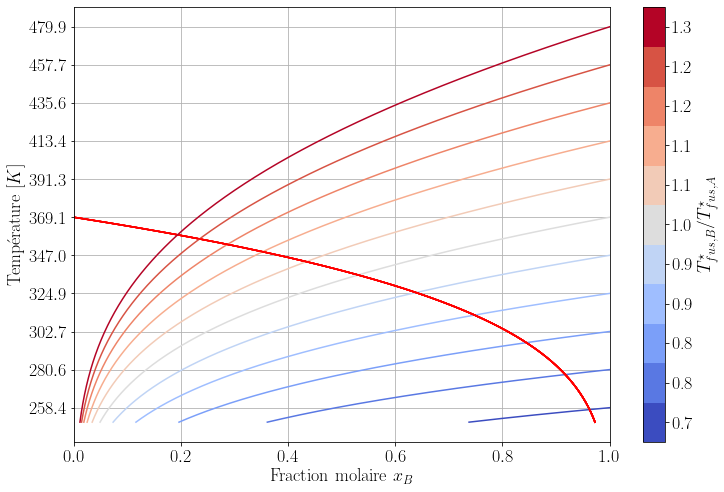

In [130]:
TfusA = 96 + 273.15
TfusB = TfusA * np.linspace(0.7, 1.3, num = 11) #(80 + 273.15)
DfusHA = 23.22 * 10**3
DfusHB = 19.44 * 10**3 #DfusHA * np.linspace(0.5, 1.5, num = 11)

pen_matplotlib=colormap(len(TfusB), name = "coolwarm")


fig = plt.figure(figsize = (12,8))
ax = fig.subplots()

for n in range(len(TfusB)) :
    
    T = np.linspace(250, TfusB[n], num = 1000)
    
    ax.plot(xB_l_1(T, DfusHA, TfusA,), T, color = 'red')
    ax.plot(xB_l_2(T, DfusHB, TfusB[n]), T, color = pen_matplotlib[n])

    ax.set_xlim(0,1)

ax.set_yticks(TfusB)

ax.set_ylabel("Température [$K$]")
ax.set_xlabel("Fraction molaire $x_B$")
ax.grid()

# Create a colorbar with discrete color labels
bounds = np.arange(len(pen_matplotlib)+1) - 0.5
cmap= mcolors.ListedColormap(pen_matplotlib)
sm = plt.cm.ScalarMappable(cmap=cmap)
sm.set_array([])  # This step is necessary to create a mappable
cbar = plt.colorbar(sm, ticks=np.arange(len(pen_matplotlib)), boundaries = bounds)
cbar.set_ticklabels(np.round(TfusB/TfusA, 1))
cbar.set_label('$T_{fus, B}^\star / T_{fus, A}^\star$')

fig.savefig("Fig03c", dpi = _dpi)